In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("day_approach_maskedID_timeseries.csv")

df.head()

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
0,1.0,5.8,0.0,0.6,1.2,0.0,0.00,0.11,0.00,0.18,...,0.0,0.0,0.0,1.0,0.10,0.00,0.15,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.5,1.2,0.0,0.0,0.10,0.00,0.17,0,0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.00,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.0,0.0,1.0,0.0,0.10,0.00,0.17,0,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,1.08,0.08,0.00,0.18,...,0.0,0.0,0.0,0.0,0.11,0.00,0.17,0,0,4


In [3]:
print(f"Rows with injuries {len(df[df["injury"] == 1])}")

injured = df[df["injury"] == 1]["Athlete ID"].nunique()
all = df["Athlete ID"].nunique()
print(f"Athletes injured: {injured}\nRatio of athletes injured: {injured/all}")

Rows with injuries 583
Athletes injured: 63
Ratio of athletes injured: 0.8513513513513513


## Random Forest Modeling

In [4]:
# Get unique athlete IDs
athletes = df["Athlete ID"].unique()

# Split athlete IDs into train and test (60-20-20 split)
trainval_athletes, test_athletes = train_test_split(athletes, test_size=0.2, random_state=42)
train_athletes, val_athletes = train_test_split(trainval_athletes, test_size=0.25, random_state=42)


# Assign rows based on athlete split
train_df = df[df["Athlete ID"].isin(train_athletes)]
val_df = df[df["Athlete ID"].isin(val_athletes)]
test_df = df[df["Athlete ID"].isin(test_athletes)]

# Split
X_train = train_df.drop(columns=["Athlete ID", "injury", "Date"])
y_train = train_df["injury"]

X_val = val_df.drop(columns=["Athlete ID", "injury", "Date"])
y_val = val_df["injury"]

X_test = test_df.drop(columns=["Athlete ID", "injury", "Date"])
y_test = test_df["injury"]

# Distribution check
print("Training", train_df["injury"].value_counts(normalize=True), f"Rows: {len(train_df)}", f"Unique Athletes: {len(train_df["Athlete ID"].unique())}","", sep="\n")
print("Validation", val_df["injury"].value_counts(normalize=True), f"Rows: {len(val_df)}", f"Unique Athletes: {len(val_df["Athlete ID"].unique())}","", sep="\n")
print("Testing", test_df["injury"].value_counts(normalize=True), f"Rows: {len(test_df)}", f"Unique Athletes: {len(test_df["Athlete ID"].unique())}","", sep="\n")

Training
injury
0    0.987094
1    0.012906
Name: proportion, dtype: float64
Rows: 25260
Unique Athletes: 44

Validation
injury
0    0.983928
1    0.016072
Name: proportion, dtype: float64
Rows: 11324
Unique Athletes: 15

Testing
injury
0    0.987868
1    0.012132
Name: proportion, dtype: float64
Rows: 6182
Unique Athletes: 15



### Basic Random Forest

Playing with threshold and class_weight

In [5]:
# Initialize and train probability RF with class weights (focusing more on injury class)
rfc_prob = RandomForestClassifier(n_estimators=100, random_state=42, class_weight={0: 1, 1: 100}, n_jobs=-2)
rfc_prob.fit(X_train, y_train)

# Probability predictions
y_val_proba = rfc_prob.predict_proba(X_val)[:, 1]  # Probability of class 1 (injury)

# Conversion of probabilities to binary predictions
threshold = 0.1 # 0.5 = default
y_val_pred = (y_val_proba >= threshold).astype(int)

# Model evaluation
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

# # Confusion matrix plot
# cm = confusion_matrix(y_val, y_val_pred, labels=rfc.classes_)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm,
#                               display_labels=rfc.classes_)
# disp.plot();

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     11142
           1       0.04      0.01      0.02       182

    accuracy                           0.98     11324
   macro avg       0.51      0.50      0.50     11324
weighted avg       0.97      0.98      0.97     11324

[[11098    44]
 [  180     2]]
Validation AUC: 0.5438


### Random Forest w/ Oversampling

Playing with threshold and class_weight

              precision    recall  f1-score   support

           0       0.98      0.87      0.93     11142
           1       0.01      0.10      0.02       182

    accuracy                           0.86     11324
   macro avg       0.50      0.49      0.47     11324
weighted avg       0.97      0.86      0.91     11324

[[9742 1400]
 [ 163   19]]
Validation AUC: 0.5420


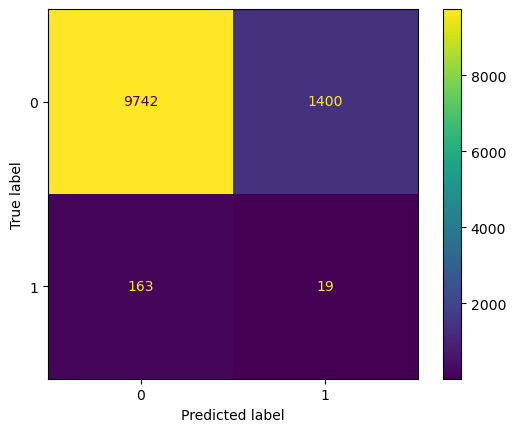

In [6]:
# SMOTE to oversample the minority class (injuries)
smote = SMOTE(sampling_strategy="auto", random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize and train probability RF with class weights (focusing more on injury class)
rfc_prob = RandomForestClassifier(n_estimators=100, random_state=42, class_weight={0: 1, 1: 10}, n_jobs=-2) # class_weight={0: 1, 1: 10}
rfc_prob.fit(X_train_resampled, y_train_resampled)

# Probability predictions
y_val_proba = rfc_prob.predict_proba(X_val)[:, 1]  # Probability of class 1 (injury)

# Conversion of probabilities to binary predictions
threshold = 0.1 # 0.5 = default
y_val_pred = (y_val_proba >= threshold).astype(int)

# Model evaluation
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))
print(f"Validation AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

# Confusion matrix plot
cm = confusion_matrix(y_val, y_val_pred, labels=rfc_prob.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=rfc_prob.classes_)
disp.plot();

### Output Interpretation

Both basic setups are struggling to find the true injuries.

We are using this setup purely to prototype the following interpretation section.

## Visualization

In [7]:
# Athlete IDs in test set
test_athletes

array([ 4, 63, 18,  0, 28, 73, 10, 34, 12, 55, 65, 31,  9, 45,  5])

In [8]:
# Setup for athlete prediction
N = 18 # athlete ID

# Data of athlete N
athlete_N = df[df["Athlete ID"] == N].sort_values(by="Date", ascending=True)

X_N = athlete_N.drop(columns=["Athlete ID", "injury", "Date"])
y_N = athlete_N["injury"]
dates_N = athlete_N["Date"] # for plot

# Make predictions (get prob of injury)
pred_prob_N = rfc_prob.predict_proba(X_N)[:, 1]  # prob of injury (class 1)
pred_N = (pred_prob_N >= threshold).astype(int)


# Predictions dataframe
athlete_N_predictions = pd.DataFrame({
    "Date": dates_N.values,
    "Injury_Probability": pred_prob_N,
    "Injury_Prediction": pred_N,
    "Injury": y_N.values})

print(athlete_N_predictions.head())

   Date  Injury_Probability  Injury_Prediction  Injury
0     0                0.02                  0       0
1     1                0.05                  0       0
2     2                0.04                  0       0
3     3                0.02                  0       0
4     4                0.02                  0       0


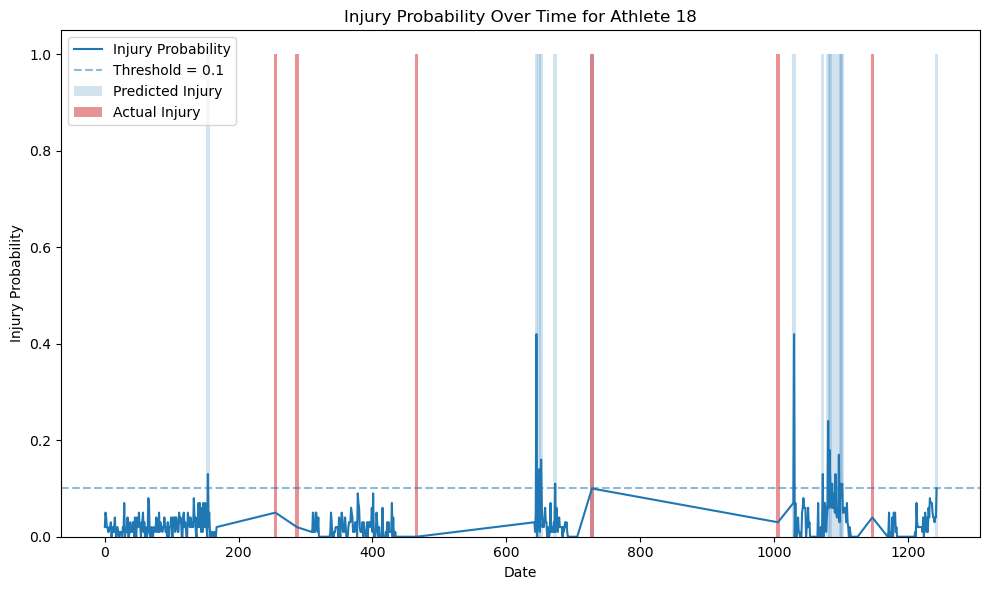

In [9]:
# Injury Probability over time
plt.figure(figsize=(10, 6))

# Predicted injury probability
plt.plot(athlete_N_predictions["Date"], athlete_N_predictions["Injury_Probability"], label="Injury Probability", color="tab:blue")
# Predicted injury status
plt.bar(athlete_N_predictions["Date"], athlete_N_predictions["Injury_Prediction"], label="Predicted Injury", width=5, color="tab:blue", alpha=0.2)
# Actual injury status
plt.bar(athlete_N_predictions["Date"], athlete_N_predictions["Injury"], label="Actual Injury", width=5, color="tab:red", alpha=0.5)
# Threshold line
plt.axhline(y=threshold, color="tab:blue", alpha=0.5, linestyle="--", label=f"Threshold = {threshold}")

plt.xlabel("Date")
plt.ylabel("Injury Probability")
plt.title(f"Injury Probability Over Time for Athlete {N}")

plt.legend()
plt.tight_layout();